In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/rafidbari/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification.git

Cloning into 'Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification'...
remote: Enumerating objects: 5848, done.
remote: Counting objects: 100% (388/388), done.
remote: Compressing objects: 100% (388/388), done.
remote: Total 5848 (delta 0), reused 388 (delta 0), pack-reused 5460 (from 2)
Receiving objects: 100% (5848/5848), 1.16 GiB | 35.65 MiB/s, done.
Updating files: 100% (5857/5857), done.


1.**DATASET** **SUMMARY**

In [ ]:
TRAIN_DIR = "/content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TRAIN"
TEST_DIR = "/content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TEST"

classes = ["NORMAL", "PNEUMONIA"]

def count_images(folder):
    extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

    return sum(
        1
        for root, dirs, files in os.walk(folder)
        for file in files
        if file.lower().endswith(extensions)
    )

summary = []

for dataset_name, dataset_path in [
    ("TRAIN", TRAIN_DIR),
    ("TEST", TEST_DIR)
]:

    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        count = count_images(class_path)

        summary.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Images": count
        })

summary_df = pd.DataFrame(summary)

print(summary_df)

  Dataset      Class  Images
0   TRAIN     NORMAL    1349
1   TRAIN  PNEUMONIA    3883
2    TEST     NORMAL     234
3    TEST  PNEUMONIA     390


In [ ]:
print("\nTotal images:")
print(summary_df["Images"].sum())

print("\nTraining images:")
print(summary_df[summary_df["Dataset"] == "TRAIN"]["Images"].sum())

print("\nTesting images:")
print(summary_df[summary_df["Dataset"] == "TEST"]["Images"].sum())


Total images:
5856

Training images:
5232

Testing images:
624


**2.Class Distribution**

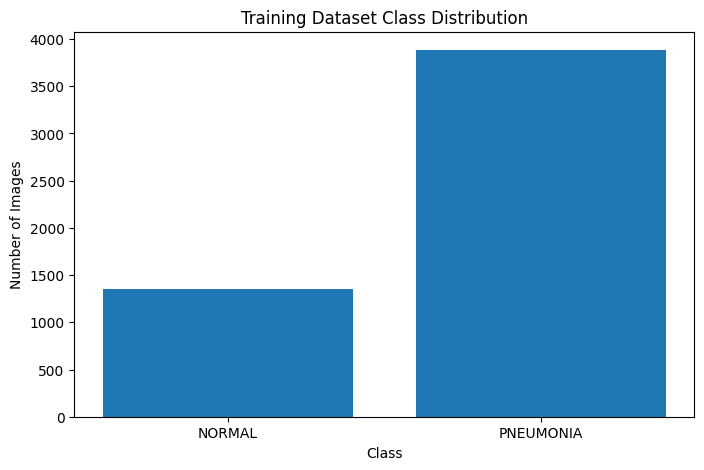

Class
NORMAL       25.78
PNEUMONIA    74.22
Name: Images, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

train_counts = summary_df[
    summary_df["Dataset"] == "TRAIN"
].set_index("Class")["Images"]

plt.figure(figsize=(8, 5))

plt.bar(train_counts.index, train_counts.values)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.show()



percentages = (
    train_counts / train_counts.sum()
) * 100

print(percentages.round(2))

Dataset    TEST  TRAIN
Class                 
NORMAL      234   1349
PNEUMONIA   390   3883


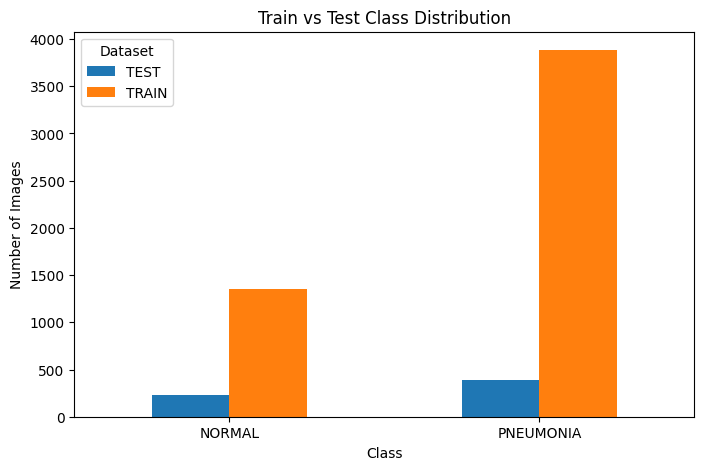

In [ ]:
distribution = summary_df.pivot(
    index="Class",
    columns="Dataset",
    values="Images"
)

print(distribution)


distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Train vs Test Class Distribution")
plt.xticks(rotation=0)
plt.show()

In [ ]:
import random
from PIL import Image

def get_images_from_class(class_path, n=6):
    files = []

    for file in os.listdir(class_path):
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        ):
            files.append(os.path.join(class_path, file))

    return random.sample(files, min(n, len(files)))


normal_images = get_images_from_class(
    os.path.join(TRAIN_DIR, "NORMAL"),
    6
)

pneumonia_images = get_images_from_class(
    os.path.join(TRAIN_DIR, "PNEUMONIA"),
    6
)

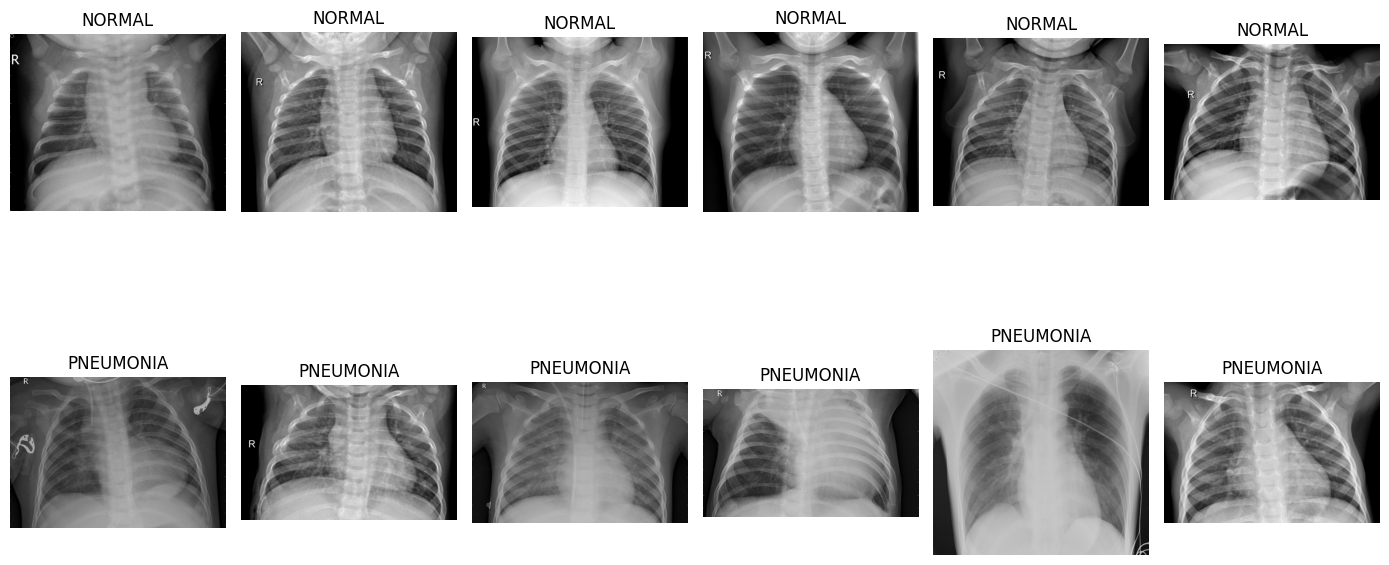

In [ ]:
plt.figure(figsize=(14, 8))

for i, path in enumerate(normal_images):
    img = Image.open(path)

    plt.subplot(2, 6, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("NORMAL")

for i, path in enumerate(pneumonia_images):
    img = Image.open(path)

    plt.subplot(2, 6, i + 7)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("PNEUMONIA")

plt.tight_layout()
plt.show()

In [ ]:
def get_image_dimensions(folder):
    dimensions = []

    for root, dirs, files in os.walk(folder):
        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):

                path = os.path.join(root, file)

                try:
                    with Image.open(path) as img:
                        dimensions.append(img.size)
                except:
                    pass

    return dimensions


train_dimensions = get_image_dimensions(TRAIN_DIR)

dimension_df = pd.DataFrame(
    train_dimensions,
    columns=["Width", "Height"]
)

print(dimension_df.describe())

             Width       Height
count  5232.000000  5232.000000
mean   1320.695336   968.181384
std     355.024600   378.542729
min     384.000000   127.000000
25%    1056.000000   688.000000
50%    1284.000000   888.000000
75%    1552.000000  1187.750000
max    2916.000000  2663.000000


Width  Height
1072   648       7
1080   728       6
1152   664       5
992    592       5
1008   680       5
976    672       5
1216   872       5
1064   760       5
1008   704       5
1072   664       4
       720       4
1192   760       4
1072   744       4
1160   800       4
1016   680       4
1176   784       4
1000   568       4
1304   968       4
1176   760       4
1000   624       4
Name: count, dtype: int64


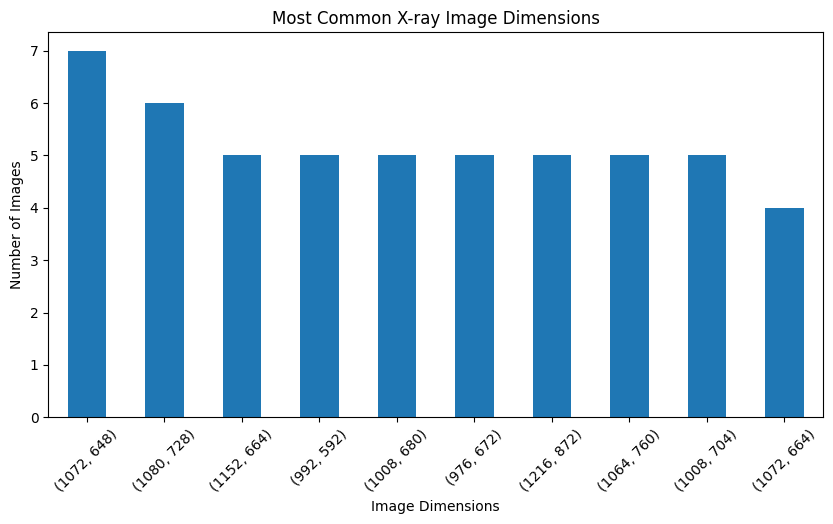

In [ ]:
print(
    dimension_df.value_counts().head(20)
)

dimension_counts = dimension_df.value_counts().head(10)

plt.figure(figsize=(10, 5))

dimension_counts.plot(kind="bar")

plt.xlabel("Image Dimensions")
plt.ylabel("Number of Images")
plt.title("Most Common X-ray Image Dimensions")

plt.xticks(rotation=45)

plt.show()

count    5232.000000
mean        1.440047
std         0.257115
min         0.835391
25%         1.257206
50%         1.411426
75%         1.583333
max         3.378788
Name: Aspect_Ratio, dtype: float64


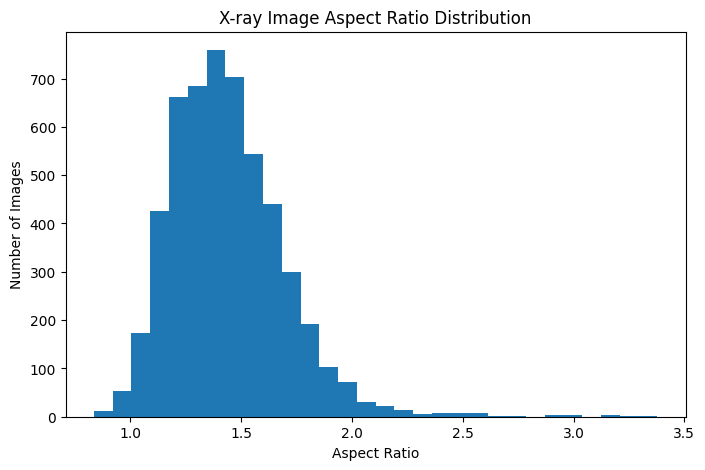

In [ ]:
dimension_df["Aspect_Ratio"] = (
    dimension_df["Width"] /
    dimension_df["Height"]
)

print(dimension_df["Aspect_Ratio"].describe())


plt.figure(figsize=(8, 5))

plt.hist(
    dimension_df["Aspect_Ratio"],
    bins=30
)

plt.xlabel("Aspect Ratio")
plt.ylabel("Number of Images")
plt.title("X-ray Image Aspect Ratio Distribution")

plt.show()

In [ ]:

mode_counts = Counter()

for root, dirs, files in os.walk(TRAIN_DIR):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        ):

            path = os.path.join(root, file)

            try:
                img = Image.open(path)
                mode_counts[img.mode] += 1
            except:
                pass

print(mode_counts)

Counter({'L': 4949, 'RGB': 283})


In [ ]:
def calculate_intensity(folder):

    records = []

    for class_name in classes:

        class_path = os.path.join(folder, class_name)

        for file in os.listdir(class_path):

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):

                path = os.path.join(class_path, file)

                try:
                    img = Image.open(path).convert("L")
                    arr = np.array(img)

                    records.append({
                        "Class": class_name,
                        "Mean": arr.mean(),
                        "Std": arr.std()
                    })

                except:
                    pass

    return pd.DataFrame(records)

In [ ]:
intensity_df = calculate_intensity(TRAIN_DIR)

intensity_df.head()

,Class,Mean,Std
0,NORMAL,119.132223,63.306820
1,NORMAL,131.390673,73.465205
2,NORMAL,128.288975,57.032487
3,NORMAL,112.050268,69.407632
4,NORMAL,133.532070,55.685560


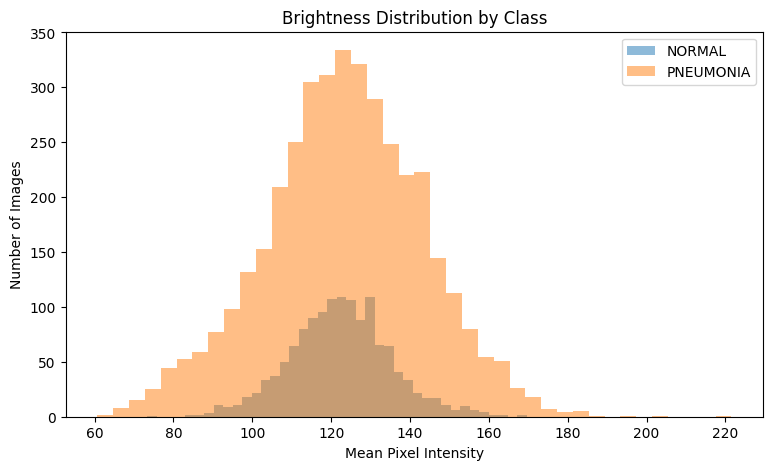

In [ ]:
plt.figure(figsize=(9, 5))

for class_name in classes:

    values = intensity_df[
        intensity_df["Class"] == class_name
    ]["Mean"]

    plt.hist(
        values,
        bins=40,
        alpha=0.5,
        label=class_name
    )

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")
plt.title("Brightness Distribution by Class")
plt.legend()

plt.show()



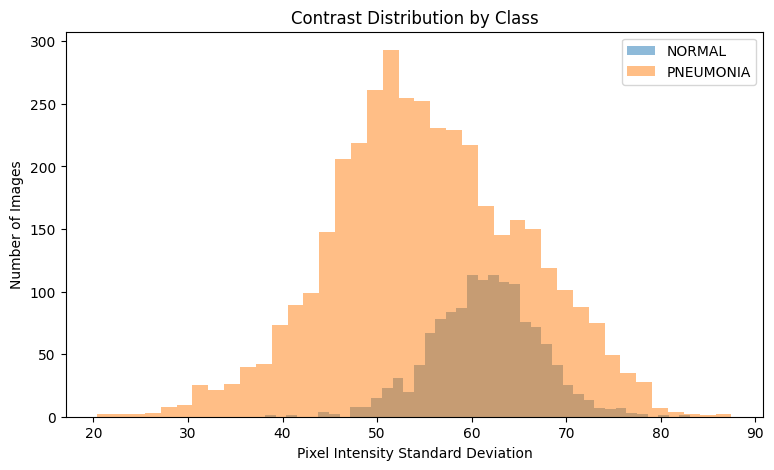

In [ ]:
plt.figure(figsize=(9, 5))

for class_name in classes:

    values = intensity_df[
        intensity_df["Class"] == class_name
    ]["Std"]

    plt.hist(
        values,
        bins=40,
        alpha=0.5,
        label=class_name
    )

plt.xlabel("Pixel Intensity Standard Deviation")
plt.ylabel("Number of Images")
plt.title("Contrast Distribution by Class")
plt.legend()

plt.show()

In [ ]:
def find_corrupted_images(folder):

    corrupted = []

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):

                path = os.path.join(root, file)

                try:
                    img = Image.open(path)
                    img.verify()

                except Exception:
                    corrupted.append(path)

    return corrupted


corrupted_train = find_corrupted_images(TRAIN_DIR)
corrupted_test = find_corrupted_images(TEST_DIR)

print("Corrupted training images:", len(corrupted_train))
print("Corrupted testing images:", len(corrupted_test))

Corrupted training images: 0
Corrupted testing images: 0


# **LOCATIONG AND DELETING DUPLICATE IMAGES**

In [ ]:
import hashlib
def find_and_delete_duplicates(folder):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder):
        for file in files:

            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):

                path = os.path.join(root, file)

                try:
                    with open(path, "rb") as f:
                        file_hash = hashlib.md5(f.read()).hexdigest()

                    if file_hash in hashes:

                        original = hashes[file_hash]
                        duplicates.append((path, original))

                    else:

                        hashes[file_hash] = path

                except Exception as e:
                    print("Error:", path, e)


    for duplicate, original in duplicates:
        try:
            os.remove(duplicate)
            print("Deleted:", duplicate)
            print("Kept:   ", original)
        except Exception as e:
            print("Could not delete:", duplicate, e)

    return duplicates


duplicates_train = find_and_delete_duplicates(TRAIN_DIR)

print("\nTotal duplicate images deleted:", len(duplicates_train))

Deleted: /content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TRAIN/PNEUMONIA/BACTERIA-6660769-0005.jpeg
Kept:    /content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TRAIN/PNEUMONIA/BACTERIA-6660769-0006.jpeg
Deleted: /content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TRAIN/PNEUMONIA/BACTERIA-7564600-0005.jpeg
Kept:    /content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TRAIN/PNEUMONIA/BACTERIA-7564600-0004.jpeg
Deleted: /content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TRAIN/PNEUMONIA/BACTERIA-4615614-0003.jpeg
Kept:    /content/Human-in-the-Loop-Active-Learning-for-Reducing-Annotation-Cost-in-Medical-Image-Classification/DATASETS/TRAIN/PNEUMONIA/BACTERIA-4615614-0004.jpeg
Deleted: /

In [ ]:
def image_hashes(folder):

    hashes = {}

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):

                path = os.path.join(root, file)

                try:
                    with open(path, "rb") as f:
                        h = hashlib.md5(
                            f.read()
                        ).hexdigest()

                    hashes[h] = path

                except:
                    pass

    return hashes


train_hashes = image_hashes(TRAIN_DIR)
test_hashes = image_hashes(TEST_DIR)

overlap = set(train_hashes.keys()) & set(test_hashes.keys())

print("Images appearing in both TRAIN and TEST:", len(overlap))

Images appearing in both TRAIN and TEST: 0


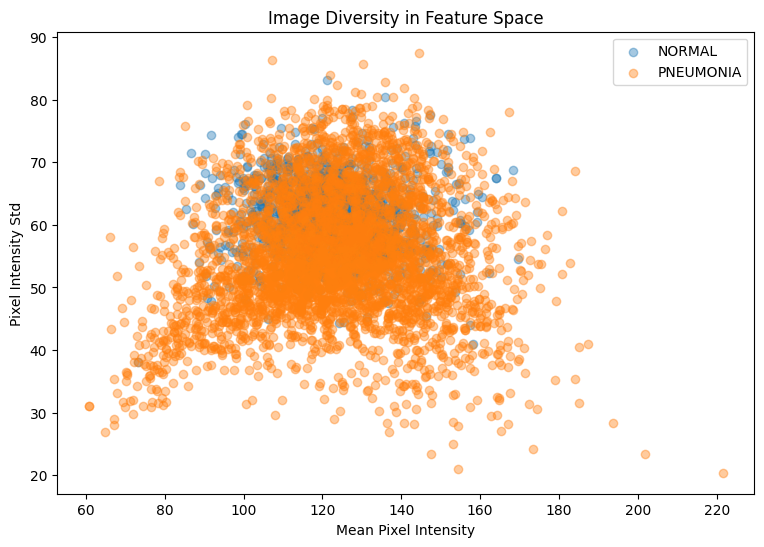

In [ ]:
diversity_df = intensity_df.copy()

plt.figure(figsize=(9, 6))

for class_name in classes:

    subset = diversity_df[
        diversity_df["Class"] == class_name
    ]

    plt.scatter(
        subset["Mean"],
        subset["Std"],
        alpha=0.4,
        label=class_name
    )

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Pixel Intensity Std")
plt.title("Image Diversity in Feature Space")
plt.legend()

plt.show()

In [ ]:
print("=" * 60)
print("CHEST X-RAY DATASET EDA SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Classes:", classes)

print("\nTraining:")
print(summary_df[summary_df["Dataset"] == "TRAIN"])

print("\nTesting:")
print(summary_df[summary_df["Dataset"] == "TEST"])

print("\nImage Dimensions:")
print(dimension_df[["Width", "Height"]].describe())

print("\nImage Modes:")
print(mode_counts)

print("\nCorrupted Images:")
print("TRAIN:", len(corrupted_train))
print("TEST :", len(corrupted_test))

print("\nDuplicate Training Images:")
print(len(duplicates_train))

print("\nTrain-Test Overlap:")
print(len(overlap))

CHEST X-RAY DATASET EDA SUMMARY

Dataset:
Classes: ['NORMAL', 'PNEUMONIA']

Training:
  Dataset      Class  Images
0   TRAIN     NORMAL    1349
1   TRAIN  PNEUMONIA    3883

Testing:
  Dataset      Class  Images
2    TEST     NORMAL     234
3    TEST  PNEUMONIA     390

Image Dimensions:
             Width       Height
count  5232.000000  5232.000000
mean   1320.695336   968.181384
std     355.024600   378.542729
min     384.000000   127.000000
25%    1056.000000   688.000000
50%    1284.000000   888.000000
75%    1552.000000  1187.750000
max    2916.000000  2663.000000

Image Modes:
Counter({'L': 4949, 'RGB': 283})

Corrupted Images:
TRAIN: 0
TEST : 0

Duplicate Training Images:
26

Train-Test Overlap:
0


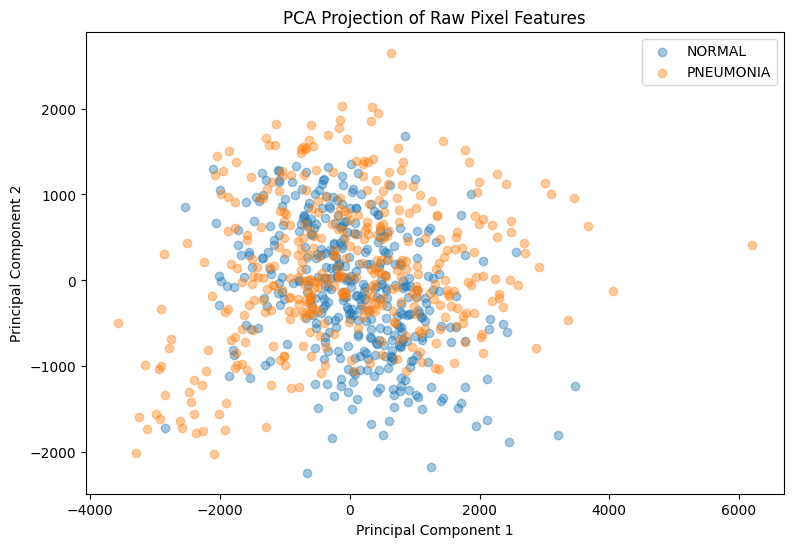

Explained variance ratio: [0.24896187 0.10814091]
Overlap between classes in this 2D projection suggests raw pixels alone
are not fully separable — motivating a learned CNN feature extractor
for the active learning uncertainty/diversity sampling strategy.


In [ ]:
from sklearn.decomposition import PCA

def build_feature_matrix(folder, size=(64, 64), sample_per_class=400):
    X, y = [], []
    for class_name in classes:
        class_path = os.path.join(folder, class_name)
        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
        sample = random.sample(files, min(sample_per_class, len(files)))

        for file in sample:
            path = os.path.join(class_path, file)
            try:
                img = Image.open(path).convert("L").resize(size)
                X.append(np.array(img).flatten())
                y.append(class_name)
            except:
                pass

    return np.array(X), np.array(y)

X_feat, y_feat = build_feature_matrix(TRAIN_DIR)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_feat)

plt.figure(figsize=(9, 6))
for class_name in classes:
    mask = y_feat == class_name
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, label=class_name)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Raw Pixel Features")
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Overlap between classes in this 2D projection suggests raw pixels alone")
print("are not fully separable — motivating a learned CNN feature extractor")
print("for the active learning uncertainty/diversity sampling strategy.")

## **PREPROCESSING**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

LABEL_TO_IDX = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

IDX_TO_LABEL = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
Random seed: 42


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/Medical_Active_Learning_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Results will be saved to:", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/Medical_Active_Learning_Project


In [ ]:
"Builfing a new foder without corrupted and duplicate files"
def build_manifest(folder):
    records = []

    for class_name in classes:
        class_path = os.path.join(folder, class_name)

        for file in sorted(os.listdir(class_path)):

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):
                records.append({
                    "path": os.path.join(class_path, file),
                    "label": class_name
                })

    return pd.DataFrame(records)


train_manifest = build_manifest(TRAIN_DIR)
test_manifest = build_manifest(TEST_DIR)

print("Clean training images:", len(train_manifest))
print("Test images:", len(test_manifest))

print("\nTraining distribution:")
print(train_manifest["label"].value_counts())

print("\nTest distribution:")
print(test_manifest["label"].value_counts())

Clean training images: 5206
Test images: 624

Training distribution:
label
PNEUMONIA    3858
NORMAL       1348
Name: count, dtype: int64

Test distribution:
label
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split


train_df, val_df = train_test_split(
    train_manifest,
    test_size=0.15,
    stratify=train_manifest["label"],
    random_state=SEED
)


#  Learning indexing
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_manifest = test_manifest.reset_index(drop=True)


print("Training pool:", len(train_df))
print(train_df["label"].value_counts())

print("\nValidation set:", len(val_df))
print(val_df["label"].value_counts())

print("\nTest set:", len(test_manifest))
print(test_manifest["label"].value_counts())

Training pool: 4425
label
PNEUMONIA    3279
NORMAL       1146
Name: count, dtype: int64

Validation set: 781
label
PNEUMONIA    579
NORMAL       202
Name: count, dtype: int64

Test set: 624
label
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


In [ ]:
INITIAL_LABELED_FRACTION = 0.05


all_train_indices = np.arange(len(train_df))

initial_labeled_indices, initial_unlabeled_indices = train_test_split(
    all_train_indices,
    train_size=INITIAL_LABELED_FRACTION,
    stratify=train_df["label"].map(LABEL_TO_IDX),
    random_state=SEED
)


labeled_pool_df = train_df.iloc[
    initial_labeled_indices
].copy()

unlabeled_pool_df = train_df.iloc[
    initial_unlabeled_indices
].copy()


print(
    "Initial labeled pool:",
    len(initial_labeled_indices)
)

print(
    labeled_pool_df["label"].value_counts()
)


print(
    "\nInitial unlabeled pool:",
    len(initial_unlabeled_indices)
)

print(
    unlabeled_pool_df["label"].value_counts()
)

Initial labeled pool: 221
label
PNEUMONIA    164
NORMAL        57
Name: count, dtype: int64

Initial unlabeled pool: 4204
label
PNEUMONIA    3115
NORMAL       1089
Name: count, dtype: int64


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [ ]:
def make_dataset(
    dataframe,
    training=False,
    batch_size=BATCH_SIZE
):

    paths = dataframe["path"].astype(str).values

    labels = (
        dataframe["label"]
        .map(LABEL_TO_IDX)
        .astype("int32")
        .values
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [ ]:
full_train_data = make_dataset(
    train_df,
    training=True
)

val_data = make_dataset(
    val_df,
    training=False
)

test_data = make_dataset(
    test_manifest,
    training=False
)


print("Datasets successfully created.")

Datasets successfully created.


In [ ]:
train_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "train_pool.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "validation_set.csv"
    ),
    index=False
)

test_manifest.to_csv(
    os.path.join(
        SAVE_DIR,
        "test_set.csv"
    ),
    index=False
)


np.save(
    os.path.join(
        SAVE_DIR,
        "initial_labeled_indices.npy"
    ),
    initial_labeled_indices
)

np.save(
    os.path.join(
        SAVE_DIR,
        "initial_unlabeled_indices.npy"
    ),
    initial_unlabeled_indices
)


print("Dataset splits and Active Learning pools saved.")

Dataset splits and Active Learning pools saved.


# **CLASS IMBALANCE HANDELING**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight


y_full_train = (
    train_df["label"]
    .map(LABEL_TO_IDX)
    .to_numpy()
)


weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_full_train
)


class_weight = {
    0: float(weights[0]),
    1: float(weights[1])
}


print("Class weights:", class_weight)

Class weights: {0: 1.9306282722513088, 1: 0.6747483989021043}


In [ ]:
from tensorflow.keras import layers


def make_augmentation():

    return tf.keras.Sequential([

        layers.RandomRotation(
            factor=0.02,
            fill_mode="nearest"
        ),

        layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="nearest"
        ),

        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="nearest"
        ),

        layers.RandomContrast(
            factor=0.10
        )

    ], name="augmentation")

**Call back func**

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)


def make_callbacks(model_name):

    model_path = os.path.join(
        SAVE_DIR,
        f"{model_name}_best.keras"
    )


    callbacks = [

        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        ),

        ModelCheckpoint(
            model_path,
            monitor="val_loss",
            save_best_only=True,
            mode="min"
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7
        )
    ]

    return callbacks, model_path

# PIPELINE

# **MODEL-1:DENSENET-121(FROZEN)**

In [ ]:
from tensorflow.keras import Model, Input
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dropout,
    Dense
)

def build_densenet():

    inputs = Input(
        shape=(224, 224, 3)
    )


    x = make_augmentation()(inputs)


    x = tf.keras.applications.densenet.preprocess_input(
        x
    )


    backbone = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )


    backbone.trainable = False


    x = backbone(
        x,
        training=False
    )


    x = GlobalAveragePooling2D(
        name="embedding"
    )(x)


    x = Dropout(
        0.4
    )(x)


    outputs = Dense(
        2,
        activation="softmax"
    )(x)


    model = Model(
        inputs,
        outputs,
        name="DenseNet121_Frozen"
    )


    return model, backbone

In [ ]:
densenet_model, densenet_backbone = build_densenet()


densenet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)


densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding                       │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,039,554 (26.85 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
densenet_callbacks, densenet_path = make_callbacks(
    "DenseNet121"
)


history_densenet = densenet_model.fit(

    full_train_data,

    validation_data=val_data,

    epochs=20,

    class_weight=class_weight,

    callbacks=densenet_callbacks
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 66s 346ms/step - accuracy: 0.7383 - loss: 0.5522 - val_accuracy: 0.9270 - val_loss: 0.2104 - learning_rate: 0.0010
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.8829 - loss: 0.2797 - val_accuracy: 0.9424 - val_loss: 0.1583 - learning_rate: 0.0010
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.9078 - loss: 0.2274 - val_accuracy: 0.9398 - val_loss: 0.1460 - learning_rate: 0.0010
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 35s 253ms/step - accuracy: 0.9146 - loss: 0.2065 - val_accuracy: 0.9398 - val_loss: 0.1512 - learning_rate: 0.0010
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 260ms/step - accuracy: 0.9198 - loss: 0.1934 - val_accuracy: 0.9283 - val_loss: 0.2047 - learning_rate: 0.0010
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 261ms/step - accuracy: 0.9155 - loss: 0.1975 - val_accuracy: 0.9449 - val_loss: 0.1337 - learning_rate: 2.0000e-04
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 262ms/step - accuracy:

In [ ]:
pd.DataFrame(
    history_densenet.history
).to_csv(
    os.path.join(
        SAVE_DIR,
        "DenseNet121_history.csv"
    ),
    index=False
)

# DENSENET 121 TRained

# **MODEL-2:CUSTOM CNN BASELINE**

In [ ]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    ReLU,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Rescaling
)


def build_cnn():

    inputs = Input(
        shape=(224, 224, 3)
    )

    x = make_augmentation()(inputs)

    x = Rescaling(
        1.0 / 255.0
    )(x)


    # Block 1
    x = Conv2D(
        32,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D()(x)


    # Block 2
    x = Conv2D(
        64,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D()(x)


    # Block 3
    x = Conv2D(
        128,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D()(x)


    x = GlobalAveragePooling2D(
        name="embedding"
    )(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(0.4)(x)


    outputs = Dense(
        2,
        activation="softmax"
    )(x)


    model = Model(
        inputs,
        outputs,
        name="Custom_CNN"
    )

    return model

In [ ]:
cnn_model = build_cnn()


cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)


cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding                       │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,690 (432.38 KB)

 Trainable params: 110,242 (430.63 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_callbacks, cnn_path = make_callbacks(
    "CNN"
)


history_cnn = cnn_model.fit(

    full_train_data,

    validation_data=val_data,

    epochs=20,

    class_weight=class_weight,

    callbacks=cnn_callbacks
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.8217 - loss: 0.3878 - val_accuracy: 0.7414 - val_loss: 1.3659 - learning_rate: 0.0010
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 243ms/step - accuracy: 0.8712 - loss: 0.3046 - val_accuracy: 0.7414 - val_loss: 1.3000 - learning_rate: 0.0010
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 40s 233ms/step - accuracy: 0.8721 - loss: 0.3027 - val_accuracy: 0.7362 - val_loss: 1.9017 - learning_rate: 0.0010
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 39s 280ms/step - accuracy: 0.8856 - loss: 0.2776 - val_accuracy: 0.2650 - val_loss: 1.6190 - learning_rate: 0.0010
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 242ms/step - accuracy: 0.8976 - loss: 0.2400 - val_accuracy: 0.3726 - val_loss: 2.3018 - learning_rate: 2.0000e-04
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 35s 247ms/step - accuracy: 0.9031 - loss: 0.2363 - val_accuracy: 0.8553 - val_loss: 0.3147 - learning_rate: 2.0000e-04
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 41s 245ms/step - accur

In [ ]:
pd.DataFrame(
    history_cnn.history
).to_csv(
    os.path.join(
        SAVE_DIR,
        "CNN_history.csv"
    ),
    index=False
)

# **MODEL-3:ResNet-50**

In [ ]:
from tensorflow.keras.applications import ResNet50


def build_resnet():

    inputs = Input(
        shape=(224, 224, 3)
    )


    x = make_augmentation()(inputs)


    x = tf.keras.applications.resnet50.preprocess_input(
        x
    )


    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )


    backbone.trainable = False


    x = backbone(
        x,
        training=False
    )


    x = GlobalAveragePooling2D(
        name="embedding"
    )(x)


    x = Dropout(
        0.4
    )(x)


    outputs = Dense(
        2,
        activation="softmax"
    )(x)


    model = Model(
        inputs,
        outputs,
        name="ResNet50_Frozen"
    )


    return model, backbone

In [ ]:
resnet_model, resnet_backbone = build_resnet()


resnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)


resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │      4,098 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_callbacks, resnet_path = make_callbacks(
    "ResNet50"
)

history_resnet = resnet_model.fit(
    full_train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight,
    callbacks=resnet_callbacks
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 45s 268ms/step - accuracy: 0.8664 - loss: 0.3194 - val_accuracy: 0.9603 - val_loss: 0.1024 - learning_rate: 0.0010
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 38s 249ms/step - accuracy: 0.9320 - loss: 0.1704 - val_accuracy: 0.9654 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.9437 - loss: 0.1401 - val_accuracy: 0.9667 - val_loss: 0.0930 - learning_rate: 0.0010
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.9494 - loss: 0.1326 - val_accuracy: 0.9680 - val_loss: 0.0918 - learning_rate: 0.0010
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step - accuracy: 0.9566 - loss: 0.1058 - val_accuracy: 0.9706 - val_loss: 0.0810 - learning_rate: 2.0000e-04
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 260ms/step - accuracy: 0.9575 - loss: 0.1034 - val_accuracy: 0.9706 - val_loss: 0.0815 - learning_rate: 2.0000e-04
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 35s 253ms/step - accur

In [ ]:
pd.DataFrame(
    history_resnet.history
).to_csv(
    os.path.join(
        SAVE_DIR,
        "ResNet50_history.csv"
    ),
    index=False
)

print("ResNet50 training history saved.")

ResNet50 training history saved.


# **VALIDATION**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


def evaluate_model(
    model,
    dataset,
    model_name,
    split_name="Test"
):

    y_true = []
    probabilities = []


    for images, labels in dataset:

        probs = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            labels.numpy()
        )

        probabilities.extend(
            probs
        )


    y_true = np.array(
        y_true
    )

    probabilities = np.array(
        probabilities
    )


    y_pred = np.argmax(
        probabilities,
        axis=1
    )


    positive_probability = probabilities[:, 1]


    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    results = {

        "Model": model_name,

        "Split": split_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                positive_probability
            ),

        "AUPRC":
            average_precision_score(
                y_true,
                positive_probability
            )
    }


    return results, cm

In [ ]:
cnn_best = tf.keras.models.load_model(
    cnn_path
)

densenet_best = tf.keras.models.load_model(
    densenet_path
)

resnet_best = tf.keras.models.load_model(
    resnet_path
)

In [ ]:
cnn_val, _ = evaluate_model(
    cnn_best,
    val_data,
    "CNN",
    "Validation"
)


dense_val, _ = evaluate_model(
    densenet_best,
    val_data,
    "DenseNet121",
    "Validation"
)


resnet_val, _ = evaluate_model(
    resnet_best,
    val_data,
    "ResNet50",
    "Validation"
)


validation_results = pd.DataFrame([
    cnn_val,
    dense_val,
    resnet_val
])


validation_results

,Model,Split,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,AUPRC
0,CNN,Validation,0.939821,0.966667,0.951641,0.905941,0.959095,0.928791,0.977248,0.992039
1,DenseNet121,Validation,0.951344,0.985637,0.948187,0.960396,0.966549,0.954291,0.990800,0.996746
2,ResNet50,Validation,0.971831,0.987741,0.974093,0.965347,0.980870,0.969720,0.996871,0.998926


selecting best model after validation

In [ ]:

validation_results_sorted = validation_results.sort_values(
    by="Balanced_Accuracy",
    ascending=False
)

print("Validation Model Ranking:")
display(validation_results_sorted)



best_index = validation_results[
    "Balanced_Accuracy"
].idxmax()

best_model_name = validation_results.loc[
    best_index,
    "Model"
]

print(
    "\nSelected Active Learning Backbone:",
    best_model_name
)

Validation Model Ranking:


,Model,Split,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,AUPRC
2,ResNet50,Validation,0.971831,0.987741,0.974093,0.965347,0.980870,0.969720,0.996871,0.998926
1,DenseNet121,Validation,0.951344,0.985637,0.948187,0.960396,0.966549,0.954291,0.990800,0.996746
0,CNN,Validation,0.939821,0.966667,0.951641,0.905941,0.959095,0.928791,0.977248,0.992039



Selected Active Learning Backbone: ResNet50


In [ ]:
validation_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "validation_model_results.csv"
    ),
    index=False
)

print("Validation results saved.")

Validation results saved.


**final evaluarion**

In [ ]:
cnn_test, cnn_cm = evaluate_model(
    cnn_best,
    test_data,
    "CNN"
)

dense_test, dense_cm = evaluate_model(
    densenet_best,
    test_data,
    "DenseNet121"
)

resnet_test, resnet_cm = evaluate_model(
    resnet_best,
    test_data,
    "ResNet50"
)


baseline_results = pd.DataFrame([
    cnn_test,
    dense_test,
    resnet_test
])


baseline_results

,Model,Split,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,AUPRC
0,CNN,Test,0.836538,0.810345,0.964103,0.623932,0.880562,0.794017,0.936785,0.960490
1,DenseNet121,Test,0.929487,0.926108,0.964103,0.871795,0.944724,0.917949,0.979509,0.988608
2,ResNet50,Test,0.899038,0.869074,0.987179,0.752137,0.924370,0.869658,0.982857,0.988722


In [ ]:
baseline_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "baseline_model_results.csv"
    ),
    index=False
)


validation_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "validation_model_results.csv"
    ),
    index=False
)

# **ACTIVE LEARNING**

In [ ]:
ACTIVE_MODEL_NAME = "ResNet50"
active_base_model = resnet_best

In [ ]:
feature_extractor = tf.keras.Model(
    inputs=active_base_model.input,
    outputs=active_base_model.get_layer(
        "embedding"
    ).output
)

**DETERMINISTIC DATASETS**

In [ ]:
train_feature_data = make_dataset(
    train_df,
    training=False
)

val_feature_data = make_dataset(
    val_df,
    training=False
)

test_feature_data = make_dataset(
    test_manifest,
    training=False
)

**feature extraction**

In [ ]:
def extract_features(
    feature_model,
    dataset,
    dataframe
):

    image_dataset = dataset.map(
        lambda x, y: x
    )

    features = feature_model.predict(
        image_dataset,
        verbose=1
    )


    labels = (
        dataframe["label"]
        .map(LABEL_TO_IDX)
        .to_numpy()
    )


    return features, labels

In [ ]:
X_train, y_train = extract_features(
    feature_extractor,
    train_feature_data,
    train_df
)


X_val, y_val = extract_features(
    feature_extractor,
    val_feature_data,
    val_df
)


X_test, y_test = extract_features(
    feature_extractor,
    test_feature_data,
    test_manifest
)

139/139 ━━━━━━━━━━━━━━━━━━━━ 43s 272ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 274ms/step


In [ ]:
np.save(
    os.path.join(
        SAVE_DIR,
        "X_train_features.npy"
    ),
    X_train
)

np.save(
    os.path.join(
        SAVE_DIR,
        "y_train.npy"
    ),
    y_train
)

np.save(
    os.path.join(
        SAVE_DIR,
        "X_val_features.npy"
    ),
    X_val
)

np.save(
    os.path.join(
        SAVE_DIR,
        "y_val.npy"
    ),
    y_val
)

np.save(
    os.path.join(
        SAVE_DIR,
        "X_test_features.npy"
    ),
    X_test
)

np.save(
    os.path.join(
        SAVE_DIR,
        "y_test.npy"
    ),
    y_test
)

**CLASSIFICATION HEAD FOR ACTIVE LEARNING**

In [ ]:
def build_active_head(
    feature_dimension
):

    inputs = tf.keras.Input(
        shape=(feature_dimension,)
    )

    x = Dropout(
        0.4
    )(inputs)

    outputs = Dense(
        2,
        activation="softmax"
    )(x)


    model = tf.keras.Model(
        inputs,
        outputs
    )


    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),

        loss=tf.keras.losses.SparseCategoricalCrossentropy(),

        metrics=["accuracy"]
    )


    return model

In [ ]:
def train_active_head(
    X_labeled,
    y_labeled,
    seed=42
):

    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(
        seed
    )


    weights = compute_class_weight(

        class_weight="balanced",

        classes=np.array([0, 1]),

        y=y_labeled
    )


    current_class_weight = {

        0: float(weights[0]),

        1: float(weights[1])
    }


    head = build_active_head(
        X_labeled.shape[1]
    )


    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True
    )


    head.fit(

        X_labeled,

        y_labeled,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=50,

        batch_size=32,

        class_weight=current_class_weight,

        callbacks=[early_stop],

        verbose=0
    )


    return head

**STRATEGY FOR ACTIVE LEARNING-1:RANDOM(to check the difference among strategies)**

In [ ]:
def random_query(
    unlabeled_indices,
    query_size,
    rng
):

    return rng.choice(

        unlabeled_indices,

        size=query_size,

        replace=False
    )

**STRATEGY FOR ACTIVE LEARNING-2:ENTROPY UNCERTAINITY**

In [ ]:
def entropy_query(
    model,
    X,
    unlabeled_indices,
    query_size
):

    probabilities = model.predict(

        X[unlabeled_indices],

        verbose=0
    )


    entropy = -np.sum(

        probabilities *
        np.log(
            probabilities + 1e-10
        ),

        axis=1
    )


    selected_positions = np.argsort(
        entropy
    )[-query_size:]


    return unlabeled_indices[
        selected_positions
    ]

**STRATEGY FOR ACTIVE LEARNING-3:HYBRID UNCERTAINITY WITH DIVERSITY**

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize


def hybrid_query(

    model,

    X,

    unlabeled_indices,

    query_size,

    seed=42,

    candidate_multiplier=3
):

    probabilities = model.predict(

        X[unlabeled_indices],

        verbose=0
    )


    entropy = -np.sum(

        probabilities *
        np.log(
            probabilities + 1e-10
        ),

        axis=1
    )


    candidate_count = min(

        len(unlabeled_indices),

        query_size *
        candidate_multiplier
    )


    candidate_positions = np.argsort(
        entropy
    )[-candidate_count:]


    candidate_indices = unlabeled_indices[
        candidate_positions
    ]


    candidate_features = normalize(
        X[candidate_indices]
    )


    kmeans = MiniBatchKMeans(

        n_clusters=query_size,

        random_state=seed,

        batch_size=256,

        n_init=5
    )


    cluster_labels = kmeans.fit_predict(
        candidate_features
    )


    selected = []


    for cluster_id in range(
        query_size
    ):

        member_positions = np.where(
            cluster_labels == cluster_id
        )[0]


        if len(member_positions) == 0:
            continue


        center = kmeans.cluster_centers_[
            cluster_id
        ]


        distances = np.linalg.norm(

            candidate_features[
                member_positions
            ] - center,

            axis=1
        )


        best_member = member_positions[
            np.argmin(distances)
        ]


        selected.append(
            candidate_indices[
                best_member
            ]
        )


    selected = np.array(
        selected,
        dtype=int
    )



    if len(selected) < query_size:

        remaining = np.setdiff1d(

            candidate_indices,

            selected
        )


        extra = remaining[
            :query_size - len(selected)
        ]


        selected = np.concatenate([
            selected,
            extra
        ])


    return selected

**EVALUATION**

In [ ]:
def evaluate_active_model(
    model,
    X,
    y
):

    probabilities = model.predict(
        X,
        verbose=0
    )


    predictions = np.argmax(
        probabilities,
        axis=1
    )


    positive_probs = probabilities[:, 1]


    tn, fp, fn, tp = confusion_matrix(
        y,
        predictions
    ).ravel()


    specificity = tn / (
        tn + fp
    )


    return {

        "Accuracy":
            accuracy_score(
                y,
                predictions
            ),

        "Precision":
            precision_score(
                y,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                predictions,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y,
                predictions,
                zero_division=0
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                positive_probs
            ),

        "AUPRC":
            average_precision_score(
                y,
                positive_probs
            )
    }

**HUMAN IN THE LOOP SIMULATION**

In [ ]:
LABEL_BUDGETS = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40
]

In [ ]:
def run_active_learning(
    strategy,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )


    labeled_indices = (
        initial_labeled_indices.copy()
    )


    unlabeled_indices = (
        initial_unlabeled_indices.copy()
    )


    results = []

    current_model = None


    for budget in LABEL_BUDGETS:

        target_count = int(
            round(
                budget *
                len(train_df)
            )
        )



        if (
            current_model is not None
            and
            len(labeled_indices)
            < target_count
        ):

            query_size = (
                target_count -
                len(labeled_indices)
            )


            if strategy == "Random":

                selected = random_query(

                    unlabeled_indices,

                    query_size,

                    rng
                )


            elif strategy == "Entropy":

                selected = entropy_query(

                    current_model,

                    X_train,

                    unlabeled_indices,

                    query_size
                )


            elif strategy == "Hybrid":

                selected = hybrid_query(

                    current_model,

                    X_train,

                    unlabeled_indices,

                    query_size,

                    seed=seed
                )


            else:

                raise ValueError(
                    "Unknown strategy"
                )


            # Simulated human annotation:
            # labels are revealed ONLY after selection

            labeled_indices = np.concatenate([
                labeled_indices,
                selected
            ])


            unlabeled_indices = np.setdiff1d(

                unlabeled_indices,

                selected
            )


        # Retrain classifier from scratch
        current_model = train_active_head(

            X_train[
                labeled_indices
            ],

            y_train[
                labeled_indices
            ],

            seed=seed
        )


        metrics = evaluate_active_model(

            current_model,

            X_test,

            y_test
        )


        metrics.update({

            "Strategy":
                strategy,

            "Labeled_Count":
                len(
                    labeled_indices
                ),

            "Labeled_Percent":
                100 *
                len(labeled_indices)
                / len(train_df)
        })


        results.append(
            metrics
        )


        print(

            strategy,

            f"{metrics['Labeled_Percent']:.1f}%",

            f"F1={metrics['F1']:.4f}",

            f"Balanced Accuracy={metrics['Balanced_Accuracy']:.4f}"
        )


    return pd.DataFrame(
        results
    )

**STRATEGIES IMPLEMENTATION**

In [ ]:
random_results = run_active_learning(
    "Random",
    seed=42
)

Random 5.0% F1=0.8841 Balanced Accuracy=0.8098
Random 10.0% F1=0.9084 Balanced Accuracy=0.8487
Random 15.0% F1=0.8908 Balanced Accuracy=0.8218
Random 20.0% F1=0.8928 Balanced Accuracy=0.8094
Random 30.0% F1=0.9165 Balanced Accuracy=0.8556
Random 40.0% F1=0.9104 Balanced Accuracy=0.8410


In [ ]:
entropy_results = run_active_learning(
    "Entropy",
    seed=42
)

Entropy 5.0% F1=0.8841 Balanced Accuracy=0.8098
Entropy 10.0% F1=0.9112 Balanced Accuracy=0.8440
Entropy 15.0% F1=0.9065 Balanced Accuracy=0.8308
Entropy 20.0% F1=0.9169 Balanced Accuracy=0.8538
Entropy 30.0% F1=0.9142 Balanced Accuracy=0.8449
Entropy 40.0% F1=0.9097 Balanced Accuracy=0.8372


In [ ]:
hybrid_results = run_active_learning(
    "Hybrid",
    seed=42
)

Hybrid 5.0% F1=0.8841 Balanced Accuracy=0.8098
Hybrid 10.0% F1=0.9218 Balanced Accuracy=0.8671
Hybrid 15.0% F1=0.9330 Balanced Accuracy=0.8885
Hybrid 20.0% F1=0.9333 Balanced Accuracy=0.8868
Hybrid 30.0% F1=0.9293 Balanced Accuracy=0.8756
Hybrid 40.0% F1=0.9151 Balanced Accuracy=0.8479


In [ ]:
active_results = pd.concat(

    [
        random_results,
        entropy_results,
        hybrid_results
    ],

    ignore_index=True
)


active_results
active_results.to_csv(

    os.path.join(
        SAVE_DIR,
        "active_learning_results.csv"
    ),

    index=False
)

**PLOT FOR FINAL RESULT**



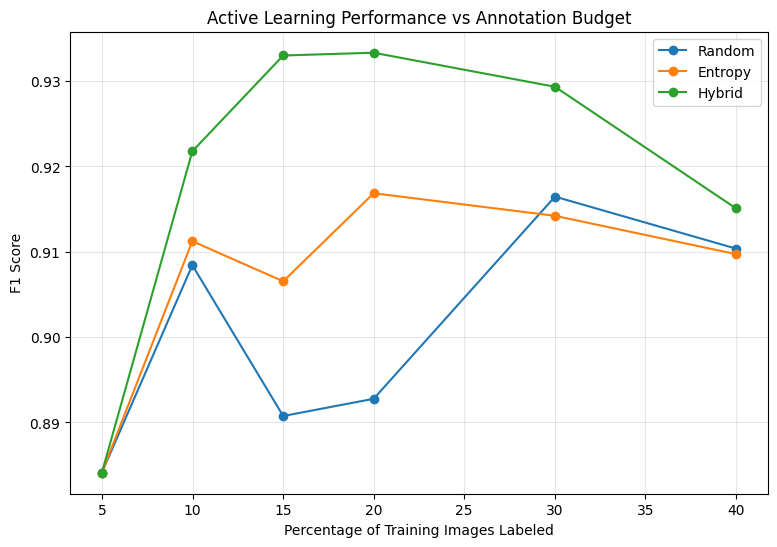

In [ ]:
import matplotlib.pyplot as plt


plt.figure(
    figsize=(9, 6)
)


for strategy in [
    "Random",
    "Entropy",
    "Hybrid"
]:

    data = active_results[
        active_results[
            "Strategy"
        ] == strategy
    ]


    plt.plot(

        data[
            "Labeled_Percent"
        ],

        data[
            "F1"
        ],

        marker="o",

        label=strategy
    )


plt.xlabel(
    "Percentage of Training Images Labeled"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Active Learning Performance vs Annotation Budget"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

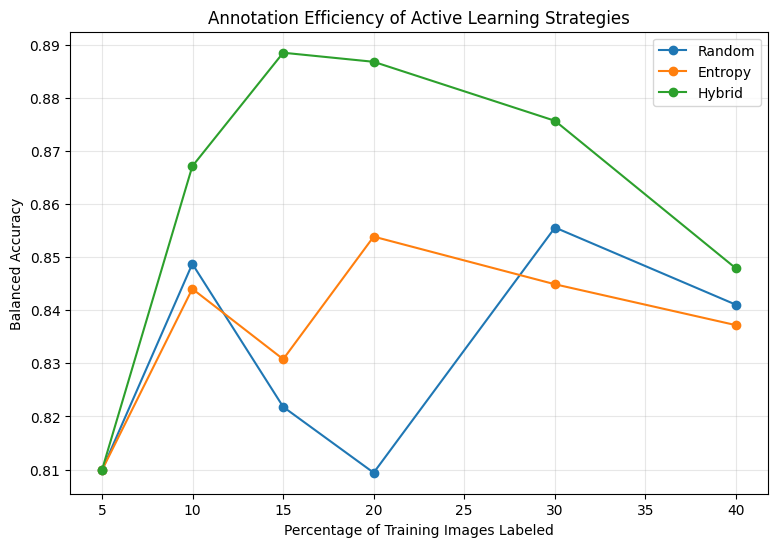

In [ ]:
plt.figure(
    figsize=(9, 6)
)


for strategy in [
    "Random",
    "Entropy",
    "Hybrid"
]:

    data = active_results[
        active_results[
            "Strategy"
        ] == strategy
    ]


    plt.plot(

        data[
            "Labeled_Percent"
        ],

        data[
            "Balanced_Accuracy"
        ],

        marker="o",

        label=strategy
    )


plt.xlabel(
    "Percentage of Training Images Labeled"
)

plt.ylabel(
    "Balanced Accuracy"
)

plt.title(
    "Annotation Efficiency of Active Learning Strategies"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

**FULL SUPERVISION ACTIVE LEARNING**

In [ ]:
full_reference_model = train_active_head(

    X_train,

    y_train,

    seed=SEED
)


full_reference_metrics = evaluate_active_model(

    full_reference_model,

    X_test,

    y_test
)


full_reference_metrics

{'Accuracy': 0.8766025641025641,
 'Precision': 0.838012958963283,
 'Recall': 0.9948717948717949,
 'Specificity': np.float64(0.6794871794871795),
 'F1': 0.9097303634232122,
 'Balanced_Accuracy': np.float64(0.8371794871794872),
 'ROC_AUC': np.float64(0.9874205566513259),
 'AUPRC': np.float64(0.9922560983727469)}

In [ ]:
target_f1 = (
    0.95 *
    full_reference_metrics["F1"]
)


print(
    "95% of full-supervised F1:",
    target_f1
)

95% of full-supervised F1: 0.8642438452520516


In [ ]:
target_f1_99 = (
    0.99 *
    full_reference_metrics["F1"]
)

print(
    "99% of full-supervised F1:",
    target_f1_99
)

In [ ]:
savings_results = []


for strategy in [
    "Random",
    "Entropy",
    "Hybrid"
]:

    subset = active_results[
        active_results[
            "Strategy"
        ] == strategy
    ].sort_values(
        "Labeled_Percent"
    )


    reached = subset[
        subset[
            "F1"
        ] >= target_f1
    ]


    if len(reached) > 0:

        first = reached.iloc[0]

        labeled_percentage = (
            first["Labeled_Percent"]
        )

        annotation_saving = (
            100 -
            labeled_percentage
        )


        savings_results.append({

            "Strategy":
                strategy,

            "Labels_Required_%":
                labeled_percentage,

            "Annotation_Saving_%":
                annotation_saving,

            "F1":
                first["F1"]
        })


savings_df = pd.DataFrame(
    savings_results
)


savings_df

,Strategy,Labels_Required_%,Annotation_Saving_%,F1
0,Random,4.99435,95.00565,0.88411
1,Entropy,4.99435,95.00565,0.88411
2,Hybrid,4.99435,95.00565,0.88411


In [ ]:
target_f1 = (
    0.99 *
    full_reference_metrics["F1"]
)

savings_results = []

for strategy in [
    "Random",
    "Entropy",
    "Hybrid"
]:

    subset = active_results[
        active_results["Strategy"] == strategy
    ].sort_values(
        "Labeled_Percent"
    )

    reached = subset[
        subset["F1"] >= target_f1
    ]

    if len(reached) > 0:

        first = reached.iloc[0]

        savings_results.append({

            "Strategy":
                strategy,

            "Labels_Required_%":
                first["Labeled_Percent"],

            "Annotation_Saving_%":
                100 - first["Labeled_Percent"],

            "F1":
                first["F1"]
        })

    else:

        savings_results.append({

            "Strategy":
                strategy,

            "Labels_Required_%":
                np.nan,

            "Annotation_Saving_%":
                np.nan,

            "F1":
                np.nan
        })


savings_99_df = pd.DataFrame(
    savings_results
)

savings_99_df

,Strategy,Labels_Required_%,Annotation_Saving_%,F1
0,Random,9.988701,90.011299,0.908434
1,Entropy,9.988701,90.011299,0.911243
2,Hybrid,9.988701,90.011299,0.921781


In [ ]:
print(
    active_results[
        [
            "Strategy",
            "Labeled_Percent",
            "Accuracy",
            "F1",
            "Balanced_Accuracy",
            "ROC_AUC"
        ]
    ].to_string(
        index=False
    )
)

Strategy  Labeled_Percent  Accuracy       F1  Balanced_Accuracy  ROC_AUC
  Random         4.994350  0.844551 0.884110           0.809829 0.955073
  Random         9.988701  0.878205 0.908434           0.848718 0.971422
  Random        15.005650  0.854167 0.890756           0.821795 0.965297
  Random        20.000000  0.852564 0.892774           0.809402 0.976540
  Random        30.011299  0.887821 0.916468           0.855556 0.981306
  Random        40.000000  0.878205 0.910377           0.841026 0.981788
 Entropy         4.994350  0.844551 0.884110           0.809829 0.955073
 Entropy         9.988701  0.879808 0.911243           0.844017 0.981777
 Entropy        15.005650  0.871795 0.906542           0.830769 0.985919
 Entropy        20.000000  0.887821 0.916865           0.853846 0.985536
 Entropy        30.011299  0.883013 0.914219           0.844872 0.986226
 Entropy        40.000000  0.876603 0.909730           0.837179 0.985689
  Hybrid         4.994350  0.844551 0.884110       


**ACTIVE LEARNING - SEED 123**


In [ ]:


random_123 = run_active_learning(
    strategy="Random",
    seed=123
)

entropy_123 = run_active_learning(
    strategy="Entropy",
    seed=123
)

hybrid_123 = run_active_learning(
    strategy="Hybrid",
    seed=123
)

seed_123_results = pd.concat(
    [
        random_123,
        entropy_123,
        hybrid_123
    ],
    ignore_index=True
)

print("Seed 123 Results:")
display(seed_123_results)

Random 5.0% F1=0.8910 Balanced Accuracy=0.8209
Random 10.0% F1=0.9080 Balanced Accuracy=0.8440
Random 15.0% F1=0.9071 Balanced Accuracy=0.8410
Random 20.0% F1=0.9061 Balanced Accuracy=0.8325
Random 30.0% F1=0.9160 Balanced Accuracy=0.8509
Random 40.0% F1=0.9072 Balanced Accuracy=0.8346
Entropy 5.0% F1=0.8910 Balanced Accuracy=0.8209
Entropy 10.0% F1=0.9266 Balanced Accuracy=0.8739
Entropy 15.0% F1=0.9125 Balanced Accuracy=0.8453
Entropy 20.0% F1=0.9044 Balanced Accuracy=0.8265
Entropy 30.0% F1=0.9108 Balanced Accuracy=0.8393
Entropy 40.0% F1=0.9162 Balanced Accuracy=0.8500
Hybrid 5.0% F1=0.8910 Balanced Accuracy=0.8209
Hybrid 10.0% F1=0.9176 Balanced Accuracy=0.8577
Hybrid 15.0% F1=0.9095 Balanced Accuracy=0.8380
Hybrid 20.0% F1=0.9065 Balanced Accuracy=0.8308
Hybrid 30.0% F1=0.9200 Balanced Accuracy=0.8611
Hybrid 40.0% F1=0.9078 Balanced Accuracy=0.8321
Seed 123 Results:


,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,AUPRC,Strategy,Labeled_Count,Labeled_Percent
0,0.854167,0.835955,0.953846,0.688034,0.891018,0.820940,0.962886,0.980533,Random,221,4.994350
1,0.876603,0.850112,0.974359,0.713675,0.908005,0.844017,0.975334,0.986503,Random,442,9.988701
2,0.875000,0.846667,0.976923,0.705128,0.907143,0.841026,0.977285,0.986939,Random,664,15.005650
3,0.871795,0.835498,0.989744,0.675214,0.906103,0.832479,0.983224,0.990340,Random,885,20.000000
4,0.886218,0.850549,0.992308,0.709402,0.915976,0.850855,0.984922,0.990940,Random,1328,30.011299
5,0.873397,0.837310,0.989744,0.679487,0.907168,0.834615,0.983213,0.989913,Random,1770,40.000000
6,0.854167,0.835955,0.953846,0.688034,0.891018,0.820940,0.962886,0.980533,Entropy,221,4.994350
7,0.902244,0.873016,0.987179,0.760684,0.926594,0.873932,0.983854,0.990283,Entropy,442,9.988701
8,0.881410,0.846491,0.989744,0.700855,0.912530,0.845299,0.984407,0.990677,Entropy,664,15.005650
9,0.868590,0.829060,0.994872,0.658120,0.904429,0.826496,0.983027,0.989448,Entropy,885,20.000000


In [ ]:
seed_123_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "active_learning_seed_123.csv"
    ),
    index=False
)

print("Seed 123 results saved.")

Seed 123 results saved.


**ACTIVE LEARNING - SEED 2026**

In [ ]:
random_2026 = run_active_learning(
    strategy="Random",
    seed=2026
)

entropy_2026 = run_active_learning(
    strategy="Entropy",
    seed=2026
)

hybrid_2026 = run_active_learning(
    strategy="Hybrid",
    seed=2026
)

seed_2026_results = pd.concat(
    [
        random_2026,
        entropy_2026,
        hybrid_2026
    ],
    ignore_index=True
)

print("Seed 2026 Results:")
display(seed_2026_results)

Random 5.0% F1=0.9111 Balanced Accuracy=0.8513
Random 10.0% F1=0.9124 Balanced Accuracy=0.8526
Random 15.0% F1=0.9310 Balanced Accuracy=0.8906
Random 20.0% F1=0.9004 Balanced Accuracy=0.8235
Random 30.0% F1=0.9091 Balanced Accuracy=0.8462
Random 40.0% F1=0.9168 Balanced Accuracy=0.8611
Entropy 5.0% F1=0.9111 Balanced Accuracy=0.8513
Entropy 10.0% F1=0.9076 Balanced Accuracy=0.8329
Entropy 15.0% F1=0.9214 Balanced Accuracy=0.8615
Entropy 20.0% F1=0.9097 Balanced Accuracy=0.8372
Entropy 30.0% F1=0.9268 Balanced Accuracy=0.8731
Entropy 40.0% F1=0.9068 Balanced Accuracy=0.8299
Hybrid 5.0% F1=0.9111 Balanced Accuracy=0.8513
Hybrid 10.0% F1=0.9091 Balanced Accuracy=0.8397
Hybrid 15.0% F1=0.8998 Balanced Accuracy=0.8197
Hybrid 20.0% F1=0.9069 Balanced Accuracy=0.8355
Hybrid 30.0% F1=0.9044 Balanced Accuracy=0.8265
Hybrid 40.0% F1=0.9026 Balanced Accuracy=0.8214
Seed 2026 Results:


,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,AUPRC,Strategy,Labeled_Count,Labeled_Percent
0,0.881410,0.857466,0.971795,0.730769,0.911058,0.851282,0.973428,0.985563,Random,221,4.994350
1,0.883013,0.857788,0.974359,0.730769,0.912365,0.852564,0.975192,0.986341,Random,442,9.988701
2,0.910256,0.895735,0.969231,0.811966,0.931034,0.890598,0.976879,0.986979,Random,664,15.005650
3,0.863782,0.829374,0.984615,0.662393,0.900352,0.823504,0.976967,0.987062,Random,885,20.000000
4,0.878205,0.852018,0.974359,0.717949,0.909091,0.846154,0.979224,0.988056,Random,1328,30.011299
5,0.889423,0.865604,0.974359,0.747863,0.916767,0.861111,0.980594,0.988590,Random,1770,40.000000
6,0.881410,0.857466,0.971795,0.730769,0.911058,0.851282,0.973428,0.985563,Entropy,221,4.994350
7,0.873397,0.834409,0.994872,0.670940,0.907602,0.832906,0.984615,0.990683,Entropy,442,9.988701
8,0.894231,0.860000,0.992308,0.730769,0.921429,0.861538,0.986566,0.991837,Entropy,664,15.005650
9,0.876603,0.838013,0.994872,0.679487,0.909730,0.837179,0.985108,0.991068,Entropy,885,20.000000


In [ ]:
seed_2026_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "active_learning_seed_2026.csv"
    ),
    index=False
)

print("Seed 2026 results saved.")

Seed 2026 results saved.


**COMBINING SEED-42,SEED-123,SEED-2026**

In [ ]:
seed_42_results = active_results.copy()

seed_42_results["Seed"] = 42


seed_123_results["Seed"] = 123
seed_2026_results["Seed"] = 2026


all_seed_results = pd.concat(
    [
        seed_42_results,
        seed_123_results,
        seed_2026_results
    ],
    ignore_index=True
)

display(all_seed_results)

,Accuracy,Precision,Recall,Specificity,F1,Balanced_Accuracy,ROC_AUC,AUPRC,Strategy,Labeled_Count,Labeled_Percent,Seed
0,0.844551,0.827740,0.948718,0.670940,0.884110,0.809829,0.955073,0.976847,Random,221,4.994350,42
1,0.878205,0.856818,0.966667,0.730769,0.908434,0.848718,0.971422,0.984597,Random,442,9.988701,42
2,0.854167,0.837472,0.951282,0.692308,0.890756,0.821795,0.965297,0.981937,Random,664,15.005650,42
3,0.852564,0.818376,0.982051,0.636752,0.892774,0.809402,0.976540,0.986556,Random,885,20.000000,42
4,0.887821,0.857143,0.984615,0.726496,0.916468,0.855556,0.981306,0.988814,Random,1328,30.011299,42
5,0.878205,0.842795,0.989744,0.692308,0.910377,0.841026,0.981788,0.989305,Random,1770,40.000000,42
6,0.844551,0.827740,0.948718,0.670940,0.884110,0.809829,0.955073,0.976847,Entropy,221,4.994350,42
7,0.879808,0.846154,0.987179,0.700855,0.911243,0.844017,0.981777,0.989108,Entropy,442,9.988701,42
8,0.871795,0.832618,0.994872,0.666667,0.906542,0.830769,0.985919,0.991591,Entropy,664,15.005650,42
9,0.887821,0.853982,0.989744,0.717949,0.916865,0.853846,0.985536,0.991282,Entropy,885,20.000000,42


**FINAL MEAN & SUMMARY**

In [ ]:
all_seed_results.to_csv(
    os.path.join(
        SAVE_DIR,
        "active_learning_all_3_seeds.csv"
    ),
    index=False
)

print("All 3-seed results saved.")

All 3-seed results saved.


In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "Balanced_Accuracy",
    "ROC_AUC",
    "AUPRC"
]


final_summary = (
    all_seed_results
    .groupby([
        "Strategy",
        "Labeled_Percent"
    ])[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

display(final_summary)

Strategy Labeled_Percent  Accuracy           Precision              Recall  \
                                 mean       std      mean       std      mean   
0   Entropy        4.994350  0.860043  0.019119  0.840387  0.015350  0.958120   
1   Entropy        9.988701  0.885150  0.015147  0.851193  0.019791  0.989744   
2   Entropy       15.005650  0.882479  0.011256  0.846370  0.013691  0.992308   
3   Entropy       20.000000  0.877671  0.009660  0.840352  0.012625  0.993162   
4   Entropy       30.011299  0.887821  0.012720  0.851659  0.017154  0.994017   
5   Entropy       40.000000  0.878205  0.007344  0.839408  0.008991  0.995726   
6    Hybrid        4.994350  0.860043  0.019119  0.840387  0.015350  0.958120   
7    Hybrid        9.988701  0.887286  0.009792  0.856664  0.013179  0.984615   
8    Hybrid       15.005650  0.883547  0.025557  0.850966  0.033436  0.988034   
9    Hybrid       20.000000  0.885684  0.022683  0.852152  0.028663  0.989744   
10   Hybrid       30.011299  0.888889  0.018712  0.854089  0.022316  0.992308   
11   Hybrid       40.000000  0.874466  0.009660  0.834764  0.011608  0.996581   
12   Random        4.994350  0.860043  0.019119  0.840387  0.015350  0.958120   
13   Random        9.988701  0.879274  0.003336  0.854906  0.004180  0.971795   
14   Random       15.005650  0.879808  0.028352  0.859958  0.031323  0.965812   
15   Random       20.000000  0.862714  0.009660  0.827749  0.008676  0.985470   
16   Random       30.011299  0.884081  0.005152  0.853237  0.003462  0.983761   
17   Random       40.000000  0.880342  0.008224  0.848570  0.015005  0.984615   

             Specificity                  F1           Balanced_Accuracy  \
         std        mean       std      mean       std              mean   
0   0.012117    0.696581  0.030817  0.895395  0.013997          0.827350   
1   0.004441    0.710826  0.045695  0.915146  0.010080          0.850285   
2   0.002564    0.699430  0.032075  0.913500  0.007491          0.845869   
3   0.002961    0.685185  0.030319  0.910341  0.006240          0.839174   
4   0.003917    0.710826  0.039708  0.917262  0.008410          0.852422   
5   0.001480    0.682336  0.021509  0.910888  0.004813          0.839031   
6   0.012117    0.696581  0.030817  0.895395  0.013997          0.827350   
7   0.002564    0.725071  0.030319  0.916145  0.006463          0.854843   
8   0.005338    0.709402  0.075967  0.914098  0.017087          0.848718   
9   0.004441    0.712251  0.064717  0.915608  0.015352          0.850997   
10  0.004441    0.716524  0.051696  0.917907  0.012581          0.854416   
11  0.001480    0.670940  0.028023  0.908488  0.006298          0.833761   
12  0.012117    0.696581  0.030817  0.895395  0.013997          0.827350   
13  0.004441    0.725071  0.009869  0.909601  0.002403          0.848433   
14  0.013158    0.736467  0.065697  0.909645  0.020255          0.851140   
15  0.003917    0.658120  0.019584  0.899743  0.006686          0.821795   
16  0.009005    0.717949  0.008547  0.913845  0.004124          0.850855   
17  0.008882    0.706553  0.036346  0.911438  0.004887          0.845584   

               ROC_AUC               AUPRC            
         std      mean       std      mean       std  
0   0.021457  0.963796  0.009211  0.980981  0.004376  
1   0.021219  0.983416  0.001469  0.990025  0.000818  
2   0.015393  0.985631  0.001108  0.991368  0.000612  
3   0.013784  0.984557  0.001343  0.990599  0.001003  
4   0.018102  0.985894  0.001128  0.991313  0.000691  
5   0.010170  0.985527  0.000315  0.991218  0.000213  
6   0.021457  0.963796  0.009211  0.980981  0.004376  
7   0.013896  0.980959  0.001445  0.988439  0.001151  
8   0.035624  0.982340  0.001254  0.989274  0.000750  
9   0.031054  0.984031  0.001295  0.990462  0.000710  
10  0.025247  0.985529  0.000971  0.991115  0.000653  
11  0.013330  0.985812  0.000836  0.991346  0.000541  
12  0.021457  0.963796  0.009211  0.980981  0.004376  
13  0.004281  0.973983  0.002219  0.

In [ ]:
f1_summary = (
    all_seed_results
    .groupby([
        "Strategy",
        "Labeled_Percent"
    ])["F1"]
    .agg(
        Mean_F1="mean",
        SD_F1="std"
    )
    .reset_index()
)

display(f1_summary)

,Strategy,Labeled_Percent,Mean_F1,SD_F1
0,Entropy,4.994350,0.895395,0.013997
1,Entropy,9.988701,0.915146,0.010080
2,Entropy,15.005650,0.913500,0.007491
3,Entropy,20.000000,0.910341,0.006240
4,Entropy,30.011299,0.917262,0.008410
5,Entropy,40.000000,0.910888,0.004813
6,Hybrid,4.994350,0.895395,0.013997
7,Hybrid,9.988701,0.916145,0.006463
8,Hybrid,15.005650,0.914098,0.017087
9,Hybrid,20.000000,0.915608,0.015352


In [ ]:
balanced_accuracy_summary = (
    all_seed_results
    .groupby([
        "Strategy",
        "Labeled_Percent"
    ])["Balanced_Accuracy"]
    .agg(
        Mean_Balanced_Accuracy="mean",
        SD_Balanced_Accuracy="std"
    )
    .reset_index()
)

display(balanced_accuracy_summary)

,Strategy,Labeled_Percent,Mean_Balanced_Accuracy,SD_Balanced_Accuracy
0,Entropy,4.994350,0.827350,0.021457
1,Entropy,9.988701,0.850285,0.021219
2,Entropy,15.005650,0.845869,0.015393
3,Entropy,20.000000,0.839174,0.013784
4,Entropy,30.011299,0.852422,0.018102
5,Entropy,40.000000,0.839031,0.010170
6,Hybrid,4.994350,0.827350,0.021457
7,Hybrid,9.988701,0.854843,0.013896
8,Hybrid,15.005650,0.848718,0.035624
9,Hybrid,20.000000,0.850997,0.031054
